# Module 7 (Supplementary): Handling Categorical Variables in Regression

This notebook is a supplementary resource for **Module 7: Multiple Regression**.

In the main Week 7 notebook, we built multiple regression models using only **numerical predictors** (Size, Bedrooms, Age, Location Rating). However, real-world datasets almost always contain **categorical variables** (e.g., Gender, City, Product Type) that cannot be directly used in regression.

This notebook covers:
1. Types of categorical variables: **Nominal** vs **Ordinal**
2. **Label Encoding** for ordinal variables
3. **One-Hot Encoding** (`pd.get_dummies()`) for nominal variables
4. Building regression models with encoded categorical variables
5. Interpreting dummy variable coefficients in regression

For the complete regression workflow (model fitting, R-squared, F-test, t-test, VIF, residual analysis), refer to the **Week 7: Multiple Regression** notebook.

In [1]:
# Setup: Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")
np.random.seed(42)
print("Setup Complete")

Setup Complete


## Section 1: Creating a Dataset with Categorical Variables

Let us create a synthetic dataset of **employee salaries** that includes both numerical and categorical variables.

| Variable | Type | Description |
|----------|------|-------------|
| Experience | Numerical | Years of work experience |
| Age | Numerical | Age in years |
| Education | Categorical (Ordinal) | High School < Bachelor's < Master's < PhD |
| Department | Categorical (Nominal) | HR, Engineering, Marketing, Finance |
| City | Categorical (Nominal) | Delhi, Bangalore, Mumbai |
| Salary | Numerical (Target) | Annual salary in lakhs |

In [2]:
# Generate synthetic employee salary dataset
np.random.seed(42)
n = 60

# Numerical variables
experience = np.random.uniform(1, 25, n).round(1)
age = (22 + experience + np.random.normal(0, 2, n)).round(0).astype(int)

# Categorical variables
education_levels = ['High School', "Bachelor's", "Master's", 'PhD']
education = np.random.choice(education_levels, n, p=[0.15, 0.40, 0.30, 0.15])

departments = ['HR', 'Engineering', 'Marketing', 'Finance']
department = np.random.choice(departments, n, p=[0.20, 0.35, 0.25, 0.20])

cities = ['Delhi', 'Bangalore', 'Mumbai']
city = np.random.choice(cities, n, p=[0.35, 0.40, 0.25])

# Generate salary based on all features
edu_effect = {'High School': 0, "Bachelor's": 3, "Master's": 7, 'PhD': 12}
dept_effect = {'HR': 0, 'Engineering': 5, 'Marketing': 2, 'Finance': 4}
city_effect = {'Delhi': 0, 'Bangalore': 3, 'Mumbai': 2}

salary = (
    5 +
    1.2 * experience +
    np.array([edu_effect[e] for e in education]) +
    np.array([dept_effect[d] for d in department]) +
    np.array([city_effect[c] for c in city]) +
    np.random.normal(0, 2, n)
).round(2)

# Create DataFrame
data = pd.DataFrame({
    'Experience': experience,
    'Age': age,
    'Education': education,
    'Department': department,
    'City': city,
    'Salary': salary
})

print("Employee Salary Dataset")
print("=" * 70)
print(f"Number of employees: {n}")
print(f"\nFirst 10 rows:")
data.head(10)

Employee Salary Dataset
Number of employees: 60

First 10 rows:


,Experience,Age,Education,Department,City,Salary
0,10.0,29,PhD,Engineering,Delhi,35.01
1,23.8,44,Bachelor's,Engineering,Bangalore,46.29
2,18.6,40,Bachelor's,Marketing,Mumbai,31.92
3,15.4,40,Master's,Finance,Bangalore,36.81
4,4.7,27,Bachelor's,Finance,Bangalore,19.69
5,4.7,23,PhD,Marketing,Delhi,23.33
6,2.4,25,PhD,Marketing,Bangalore,28.41
7,21.8,43,Bachelor's,HR,Mumbai,36.97
8,15.4,36,Bachelor's,HR,Delhi,23.96
9,18.0,41,Bachelor's,Finance,Bangalore,38.44


In [3]:
# Examine the data types
print("Data Types:")
print("=" * 40)
print(data.dtypes)
print("\nDescriptive Statistics (Numerical):")
print("=" * 40)
print(data.describe().round(2))
print("\nCategorical Variable Summary:")
print("=" * 40)
for col in ['Education', 'Department', 'City']:
    print(f"\n{col}:")
    print(data[col].value_counts())

Data Types:
Experience    float64
Age             int64
Education      object
Department     object
City           object
Salary        float64
dtype: object

Descriptive Statistics (Numerical):
       Experience    Age  Salary
count       60.00  60.00   60.00
mean        12.22  34.02   29.57
std          7.33   7.31    8.97
min          1.50  22.00   12.65
25%          5.40  28.00   23.04
50%         11.75  33.50   30.16
75%         18.15  40.00   36.85
max         24.30  48.00   48.91

Categorical Variable Summary:

Education:
Education
Bachelor's     25
Master's       16
PhD            10
High School     9
Name: count, dtype: int64

Department:
Department
Engineering    18
Marketing      17
Finance        14
HR             11
Name: count, dtype: int64

City:
City
Bangalore    27
Delhi        18
Mumbai       15
Name: count, dtype: int64


## Section 2: Types of Categorical Variables

Not all categorical variables are the same. Understanding the **type** determines **how we encode** them.

### 2.1 Ordinal Variables

**Ordinal variables** have a natural, meaningful **order** or ranking.

| Example | Categories | Order |
|---------|-----------|-------|
| Education | High School, Bachelor's, Master's, PhD | High School < Bachelor's < Master's < PhD |
| Customer Rating | Poor, Fair, Good, Excellent | Poor < Fair < Good < Excellent |
| T-shirt Size | S, M, L, XL | S < M < L < XL |

For ordinal variables, **the order matters**, so we use **Label Encoding** which assigns increasing integers.

### 2.2 Nominal Variables

**Nominal variables** have **no inherent order** -- they are just categories or labels.

| Example | Categories | Order? |
|---------|-----------|--------|
| Department | HR, Engineering, Marketing, Finance | No order |
| City | Delhi, Bangalore, Mumbai | No order |
| Color | Red, Blue, Green | No order |

For nominal variables, assigning numbers like 1, 2, 3 would incorrectly imply that one category is "greater" than another. We use **One-Hot Encoding** instead.

## Section 3: Label Encoding for Ordinal Variables

**Label Encoding** replaces each category with an integer that preserves the natural order.

For our `Education` variable:
- High School → 0
- Bachelor's → 1
- Master's → 2
- PhD → 3

This is appropriate because there is a clear ordering: PhD > Master's > Bachelor's > High School.

In [4]:
# Method 1: Manual mapping (RECOMMENDED for ordinal variables)
# This gives you full control over the order

education_mapping = {
    'High School': 0,
    "Bachelor's": 1,
    "Master's": 2,
    'PhD': 3
}

data['Education_Encoded'] = data['Education'].map(education_mapping)

print("Label Encoding for Education (Manual Mapping)")
print("=" * 50)
print("\nMapping used:")
for category, code in education_mapping.items():
    print(f"  {category:15} --> {code}")

print("\nResult:")
print(data[['Education', 'Education_Encoded']].drop_duplicates().sort_values('Education_Encoded'))

print("\nSample rows:")
data[['Experience', 'Education', 'Education_Encoded', 'Salary']].head(8)

Label Encoding for Education (Manual Mapping)

Mapping used:
  High School     --> 0
  Bachelor's      --> 1
  Master's        --> 2
  PhD             --> 3

Result:
      Education  Education_Encoded
11  High School                  0
1    Bachelor's                  1
3      Master's                  2
0           PhD                  3

Sample rows:


,Experience,Education,Education_Encoded,Salary
0,10.0,PhD,3,35.01
1,23.8,Bachelor's,1,46.29
2,18.6,Bachelor's,1,31.92
3,15.4,Master's,2,36.81
4,4.7,Bachelor's,1,19.69
5,4.7,PhD,3,23.33
6,2.4,PhD,3,28.41
7,21.8,Bachelor's,1,36.97


In [5]:
# Method 2: Using sklearn's LabelEncoder
# NOTE: LabelEncoder assigns numbers alphabetically, NOT by logical order.
# So it may NOT preserve the correct ordinal ranking.

le = LabelEncoder()
auto_encoded = le.fit_transform(data['Education'])

print("LabelEncoder assigns codes ALPHABETICALLY:")
print("=" * 50)
for label, code in zip(le.classes_, range(len(le.classes_))):
    print(f"  {label:15} --> {code}")

print("\nNotice: Bachelor's (0) < High School (1) < Master's (2) < PhD (3)")
print("This is WRONG! High School should be 0, not Bachelor's.")
print("\nFor ordinal variables, ALWAYS use manual mapping to preserve correct order.")

LabelEncoder assigns codes ALPHABETICALLY:
  Bachelor's      --> 0
  High School     --> 1
  Master's        --> 2
  PhD             --> 3

Notice: Bachelor's (0) < High School (1) < Master's (2) < PhD (3)
This is WRONG! High School should be 0, not Bachelor's.

For ordinal variables, ALWAYS use manual mapping to preserve correct order.


### Key Takeaway: Label Encoding

| Method | When to Use |
|--------|------------|
| **Manual mapping** (`.map()`) | Always preferred for ordinal variables -- you control the order |
| **LabelEncoder** (sklearn) | Quick option, but assigns codes alphabetically -- verify the order! |

**Important:** Label Encoding assumes **equal spacing** between levels (i.e., the "distance" from High School to Bachelor's is the same as Bachelor's to Master's). If this assumption is unreasonable, consider using One-Hot Encoding even for ordinal variables.

## Section 4: One-Hot Encoding for Nominal Variables

**One-Hot Encoding** creates a **separate binary (0/1) column** for each category.

For example, the `City` variable with 3 categories (Delhi, Bangalore, Mumbai) becomes:

| Original | City_Delhi | City_Bangalore | City_Mumbai |
|----------|-----------|---------------|------------|
| Delhi | 1 | 0 | 0 |
| Bangalore | 0 | 1 | 0 |
| Mumbai | 0 | 0 | 1 |
| Delhi | 1 | 0 | 0 |

Each row has exactly **one** column set to 1 (hence "one-hot").

### Why not Label Encoding for Nominal Variables?

If we encode Delhi=0, Bangalore=1, Mumbai=2, the regression model would interpret this as:
- Mumbai (2) is "twice" as much as Bangalore (1)
- Mumbai (2) - Bangalore (1) = Bangalore (1) - Delhi (0)

This is meaningless for cities! There is no numerical relationship between them.

In [6]:
# One-Hot Encoding using pd.get_dummies()
# This is the most common and convenient method in pandas

# Encode the 'City' column
city_dummies = pd.get_dummies(data['City'], prefix='City')

print("One-Hot Encoding for City")
print("=" * 50)
print("\nOriginal vs Encoded:")
print(pd.concat([data['City'], city_dummies], axis=1).head(10))
print(f"\nOriginal: 1 column with {data['City'].nunique()} categories")
print(f"Encoded:  {city_dummies.shape[1]} binary columns")

One-Hot Encoding for City

Original vs Encoded:
        City  City_Bangalore  City_Delhi  City_Mumbai
0      Delhi           False        True        False
1  Bangalore            True       False        False
2     Mumbai           False       False         True
3  Bangalore            True       False        False
4  Bangalore            True       False        False
5      Delhi           False        True        False
6  Bangalore            True       False        False
7     Mumbai           False       False         True
8      Delhi           False        True        False
9  Bangalore            True       False        False

Original: 1 column with 3 categories
Encoded:  3 binary columns


In [7]:
# Similarly, encode the 'Department' column
dept_dummies = pd.get_dummies(data['Department'], prefix='Dept')

print("One-Hot Encoding for Department")
print("=" * 50)
print("\nOriginal vs Encoded:")
print(pd.concat([data['Department'], dept_dummies], axis=1).head(10))
print(f"\nOriginal: 1 column with {data['Department'].nunique()} categories")
print(f"Encoded:  {dept_dummies.shape[1]} binary columns")

One-Hot Encoding for Department

Original vs Encoded:
    Department  Dept_Engineering  Dept_Finance  Dept_HR  Dept_Marketing
0  Engineering              True         False    False           False
1  Engineering              True         False    False           False
2    Marketing             False         False    False            True
3      Finance             False          True    False           False
4      Finance             False          True    False           False
5    Marketing             False         False    False            True
6    Marketing             False         False    False            True
7           HR             False         False     True           False
8           HR             False         False     True           False
9      Finance             False          True    False           False

Original: 1 column with 4 categories
Encoded:  4 binary columns


## Section 5: The Dummy Variable Trap

When using One-Hot Encoding in **regression**, there is an important issue called the **Dummy Variable Trap**.

### The Problem

If `City` has 3 categories and we create 3 dummy columns:
- `City_Delhi + City_Bangalore + City_Mumbai = 1` (always!)

This means one column is **perfectly predictable** from the others. This creates **perfect multicollinearity** (recall VIF from Week 7!), and the regression cannot be fitted.

### The Solution: Drop One Category

We drop one dummy column, making it the **reference category**. The remaining dummies are interpreted **relative to the dropped category**.

For example, if we drop `City_Delhi`:
- `City_Bangalore = 1` means "Bangalore compared to Delhi"
- `City_Mumbai = 1` means "Mumbai compared to Delhi"
- Both zero means the employee is in Delhi (the reference)

In [8]:
# Using drop_first=True to avoid the dummy variable trap

# WITHOUT drop_first (creates perfect multicollinearity)
city_all = pd.get_dummies(data['City'], prefix='City')
print("WITHOUT drop_first (DO NOT use in regression):")
print(city_all.head(5))
print(f"Sum of each row: {city_all.sum(axis=1).unique()}")
print("Each row sums to 1 -- perfect multicollinearity!")

print("\n" + "=" * 60)

# WITH drop_first (safe for regression)
city_dropped = pd.get_dummies(data['City'], prefix='City', drop_first=True)
print("\nWITH drop_first=True (SAFE for regression):")
print(city_dropped.head(5))
print(f"\nDropped category (reference): {sorted(data['City'].unique())[0]}")
print("When both City_Delhi and City_Mumbai are 0, the employee is in Bangalore (reference).")

WITHOUT drop_first (DO NOT use in regression):
   City_Bangalore  City_Delhi  City_Mumbai
0           False        True        False
1            True       False        False
2           False       False         True
3            True       False        False
4            True       False        False
Sum of each row: [1]
Each row sums to 1 -- perfect multicollinearity!


WITH drop_first=True (SAFE for regression):
   City_Delhi  City_Mumbai
0        True        False
1       False        False
2       False         True
3       False        False
4       False        False

Dropped category (reference): Bangalore
When both City_Delhi and City_Mumbai are 0, the employee is in Bangalore (reference).


## Section 6: Building Regression Models -- Numerical Only vs With Encoded Categoricals

Now let us see the impact of including categorical variables. We will compare two models:

- **Model 1:** Only numerical predictors (Experience, Age)
- **Model 2:** Numerical + Encoded categorical predictors (Experience, Age, Education, Department, City)

This demonstrates why encoding and including categorical variables is important for model performance.

In [9]:
# ============================================================
# MODEL 1: Only Numerical Predictors
# ============================================================

X_numerical = data[['Experience', 'Age']]
y = data['Salary']

X_numerical_const = sm.add_constant(X_numerical)
model1 = sm.OLS(y, X_numerical_const).fit()

print("MODEL 1: Numerical Predictors Only (Experience + Age)")
print("=" * 60)
print(model1.summary())

MODEL 1: Numerical Predictors Only (Experience + Age)
                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.719
Model:                            OLS   Adj. R-squared:                  0.710
Method:                 Least Squares   F-statistic:                     73.06
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           1.87e-16
Time:                        08:53:18   Log-Likelihood:                -178.12
No. Observations:                  60   AIC:                             362.2
Df Residuals:                      57   BIC:                             368.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [10]:
# ============================================================
# MODEL 2: Numerical + Encoded Categorical Predictors
# ============================================================

# Step 1: Label Encode the ordinal variable
data['Education_Encoded'] = data['Education'].map(education_mapping)

# Step 2: One-Hot Encode the nominal variables (with drop_first=True)
dept_dummies = pd.get_dummies(data['Department'], prefix='Dept', drop_first=True)
city_dummies = pd.get_dummies(data['City'], prefix='City', drop_first=True)

# Step 3: Combine all predictors
X_full = pd.concat([
    data[['Experience', 'Age', 'Education_Encoded']],
    dept_dummies,
    city_dummies
], axis=1)

print("Combined predictor matrix (first 5 rows):")
print("=" * 80)
print(X_full.head())
print(f"\nTotal predictors: {X_full.shape[1]}")
print(f"  - Numerical: Experience, Age")
print(f"  - Label Encoded: Education_Encoded")
print(f"  - One-Hot (Department): {list(dept_dummies.columns)} (reference: {sorted(data['Department'].unique())[0]})")
print(f"  - One-Hot (City): {list(city_dummies.columns)} (reference: {sorted(data['City'].unique())[0]})")

Combined predictor matrix (first 5 rows):
   Experience  Age  Education_Encoded  Dept_Finance  Dept_HR  Dept_Marketing  \
0        10.0   29                  3         False    False           False   
1        23.8   44                  1         False    False           False   
2        18.6   40                  1         False    False            True   
3        15.4   40                  2          True    False           False   
4         4.7   27                  1          True    False           False   

   City_Delhi  City_Mumbai  
0        True        False  
1       False        False  
2       False         True  
3       False        False  
4       False        False  

Total predictors: 8
  - Numerical: Experience, Age
  - Label Encoded: Education_Encoded
  - One-Hot (Department): ['Dept_Finance', 'Dept_HR', 'Dept_Marketing'] (reference: Engineering)
  - One-Hot (City): ['City_Delhi', 'City_Mumbai'] (reference: Bangalore)


In [12]:
# Fit Model 2
X_full = X_full.astype(int) # Convert boolean columns from one-hot encoding to integers
X_full_const = sm.add_constant(X_full)
model2 = sm.OLS(y, X_full_const).fit()

print("MODEL 2: Numerical + Encoded Categorical Predictors")
print("=" * 60)
print(model2.summary())

MODEL 2: Numerical + Encoded Categorical Predictors
                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     109.9
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           2.07e-29
Time:                        08:55:19   Log-Likelihood:                -129.15
No. Observations:                  60   AIC:                             276.3
Df Residuals:                      51   BIC:                             295.1
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

In [13]:
# ============================================================
# Compare Model 1 vs Model 2
# ============================================================

print("MODEL COMPARISON")
print("=" * 60)
print(f"{'Metric':<25} {'Model 1 (Num Only)':>20} {'Model 2 (Num + Cat)':>20}")
print("-" * 65)
print(f"{'R-squared':<25} {model1.rsquared:>20.4f} {model2.rsquared:>20.4f}")
print(f"{'Adjusted R-squared':<25} {model1.rsquared_adj:>20.4f} {model2.rsquared_adj:>20.4f}")
print(f"{'AIC':<25} {model1.aic:>20.2f} {model2.aic:>20.2f}")
print(f"{'BIC':<25} {model1.bic:>20.2f} {model2.bic:>20.2f}")
print(f"{'F-statistic':<25} {model1.fvalue:>20.2f} {model2.fvalue:>20.2f}")
print(f"{'Number of predictors':<25} {model1.df_model:>20.0f} {model2.df_model:>20.0f}")
print("=" * 60)
print(f"\nImprovement in Adjusted R-squared: {(model2.rsquared_adj - model1.rsquared_adj)*100:.2f} percentage points")
print("\nIncluding categorical variables significantly improves the model!")

MODEL COMPARISON
Metric                      Model 1 (Num Only)  Model 2 (Num + Cat)
-----------------------------------------------------------------
R-squared                               0.7194               0.9452
Adjusted R-squared                      0.7095               0.9366
AIC                                     362.25               276.29
BIC                                     368.53               295.14
F-statistic                              73.06               109.87
Number of predictors                         2                    8

Improvement in Adjusted R-squared: 22.70 percentage points

Including categorical variables significantly improves the model!


## Section 7: Interpreting Dummy Variable Coefficients

The coefficients of dummy variables have a specific interpretation:

**Each dummy coefficient represents the difference in the predicted value compared to the reference category, holding all other variables constant.**

For example:
- `Dept_Engineering = 5.2` means: An employee in Engineering earns Rs. 5.2 lakhs **more** than an employee in the reference department (say, Engineering), holding Experience, Age, Education, and City constant.
- `City_Mumbai = 2.1` means: Working in Mumbai adds Rs. 2.1 lakhs compared to working in the reference city (say, Bangalore), holding everything else constant.

In [14]:
# Interpreting the coefficients from Model 2
print("COEFFICIENT INTERPRETATION (Model 2)")
print("=" * 70)

coefficients = model2.params
p_values = model2.pvalues

print(f"\nIntercept: {coefficients['const']:.2f}")
print(f"  Base salary when all predictors = 0 / reference categories\n")

print("--- Numerical Variables ---")
print(f"Experience: {coefficients['Experience']:.4f} (p={p_values['Experience']:.4f})")
print(f"  Each additional year of experience increases salary by Rs. {coefficients['Experience']:.2f} lakhs\n")

print(f"Age: {coefficients['Age']:.4f} (p={p_values['Age']:.4f})")
print(f"  Note: Age may not be significant when Experience is already in the model\n")

print("--- Ordinal Variable (Label Encoded) ---")
print(f"Education: {coefficients['Education_Encoded']:.4f} (p={p_values['Education_Encoded']:.4f})")
print(f"  Each step up in education level increases salary by Rs. {coefficients['Education_Encoded']:.2f} lakhs\n")

print("--- Nominal Variables (One-Hot Encoded) ---")
ref_dept = sorted(data['Department'].unique())[0]
print(f"Department (reference: {ref_dept}):")
for col in dept_dummies.columns:
    dept_name = col.replace('Dept_', '')
    print(f"  {dept_name}: {coefficients[col]:+.4f} (p={p_values[col]:.4f})")
    print(f"    Employees in {dept_name} earn Rs. {coefficients[col]:+.2f} lakhs compared to {ref_dept}")

ref_city = sorted(data['City'].unique())[0]
print(f"\nCity (reference: {ref_city}):")
for col in city_dummies.columns:
    city_name = col.replace('City_', '')
    print(f"  {city_name}: {coefficients[col]:+.4f} (p={p_values[col]:.4f})")
    print(f"    Employees in {city_name} earn Rs. {coefficients[col]:+.2f} lakhs compared to {ref_city}")

COEFFICIENT INTERPRETATION (Model 2)

Intercept: 16.16
  Base salary when all predictors = 0 / reference categories

--- Numerical Variables ---
Experience: 1.2323 (p=0.0000)
  Each additional year of experience increases salary by Rs. 1.23 lakhs

Age: -0.0859 (p=0.6038)
  Note: Age may not be significant when Experience is already in the model

--- Ordinal Variable (Label Encoded) ---
Education: 3.7180 (p=0.0000)
  Each step up in education level increases salary by Rs. 3.72 lakhs

--- Nominal Variables (One-Hot Encoded) ---
Department (reference: Engineering):
  Finance: -1.5101 (p=0.0812)
    Employees in Finance earn Rs. -1.51 lakhs compared to Engineering
  HR: -5.0098 (p=0.0000)
    Employees in HR earn Rs. -5.01 lakhs compared to Engineering
  Marketing: -3.7257 (p=0.0000)
    Employees in Marketing earn Rs. -3.73 lakhs compared to Engineering

City (reference: Bangalore):
  Delhi: -3.4896 (p=0.0000)
    Employees in Delhi earn Rs. -3.49 lakhs compared to Bangalore
  Mumbai: -0.

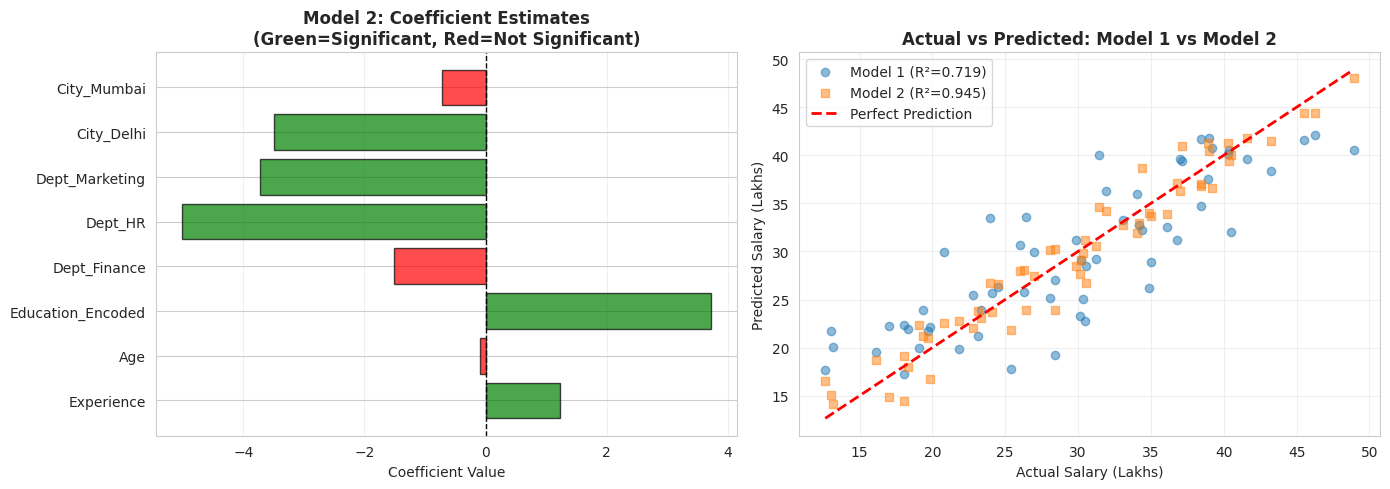

In [15]:
# Visualize the coefficients
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: All coefficients (excluding intercept)
coef_df = pd.DataFrame({
    'Variable': model2.params.index[1:],
    'Coefficient': model2.params.values[1:],
    'Significant': ['Yes' if p < 0.05 else 'No' for p in model2.pvalues.values[1:]]
})

colors = ['green' if s == 'Yes' else 'red' for s in coef_df['Significant']]
axes[0].barh(coef_df['Variable'], coef_df['Coefficient'], color=colors, alpha=0.7, edgecolor='black')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title('Model 2: Coefficient Estimates\n(Green=Significant, Red=Not Significant)', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: Actual vs Predicted comparison
y_pred1 = model1.predict(X_numerical_const)
y_pred2 = model2.predict(X_full_const)

axes[1].scatter(y, y_pred1, alpha=0.5, label=f'Model 1 (R²={model1.rsquared:.3f})', marker='o')
axes[1].scatter(y, y_pred2, alpha=0.5, label=f'Model 2 (R²={model2.rsquared:.3f})', marker='s')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Salary (Lakhs)')
axes[1].set_ylabel('Predicted Salary (Lakhs)')
axes[1].set_title('Actual vs Predicted: Model 1 vs Model 2', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 8: Quick Reference -- Encoding Decision Flowchart

Use this decision guide when you encounter a categorical variable:

```
Is the variable categorical?
│
├── YES
│   ├── Does it have a natural ORDER?
│   │   ├── YES (Ordinal)  -->  Use Label Encoding (.map() with manual order)
│   │   │                        Examples: Education level, Rating, Size (S/M/L)
│   │   │
│   │   └── NO (Nominal)   -->  Use One-Hot Encoding (pd.get_dummies(drop_first=True))
│   │                            Examples: City, Department, Color, Gender
│   │
│   └── Binary (only 2 categories)?
│       └── Either method works. Label Encoding (0/1) is simplest.
│           Examples: Gender (M/F), Smoker (Yes/No)
│
└── NO (Numerical) -->  Use directly in regression (no encoding needed)
```

### Important Reminders

1. **Always use `drop_first=True`** in `pd.get_dummies()` when building regression models to avoid the dummy variable trap.
2. **Label Encoding assumes equal spacing** between levels. Use it only when this is a reasonable assumption.
3. **Document your reference category** -- readers of your analysis need to know what the dummy coefficients are compared against.

---

For the complete regression workflow including model evaluation (R-squared, Adjusted R-squared), significance testing (F-test, t-test), multicollinearity (VIF), and residual analysis, refer to the **Week 7: Multiple Regression** notebook.